# Multiple Linear Regression

## Will people turn up for the movie?

Two films can attract different audiences even with similar online attention. Ticket prices provide another clue. Multiple linear regression combines several inputs in one prediction.

> Predicted audience = starting audience + buzz contribution + price contribution

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/03_adding_two_inputs.png" alt="Online buzz and ticket price contribute to a prediction of a movie audience." width="640" style="max-width:100%;height:auto;">

Online buzz counts teaser mentions in thousands. Ticket price is measured in thousands of won. The audience is the number of opening-day tickets sold, also in thousands. Every record describes a simulated movie release across many cinemas.

Each coefficient describes a change in the model's prediction while the other input stays fixed. A higher price is associated with a smaller audience in this dataset. This association does not establish what a real price change would cause.

The controls choose a movie's buzz and price. Blue records have similar prices; gray records have other prices. The line holds the selected price fixed, and the orange dot uses both inputs.


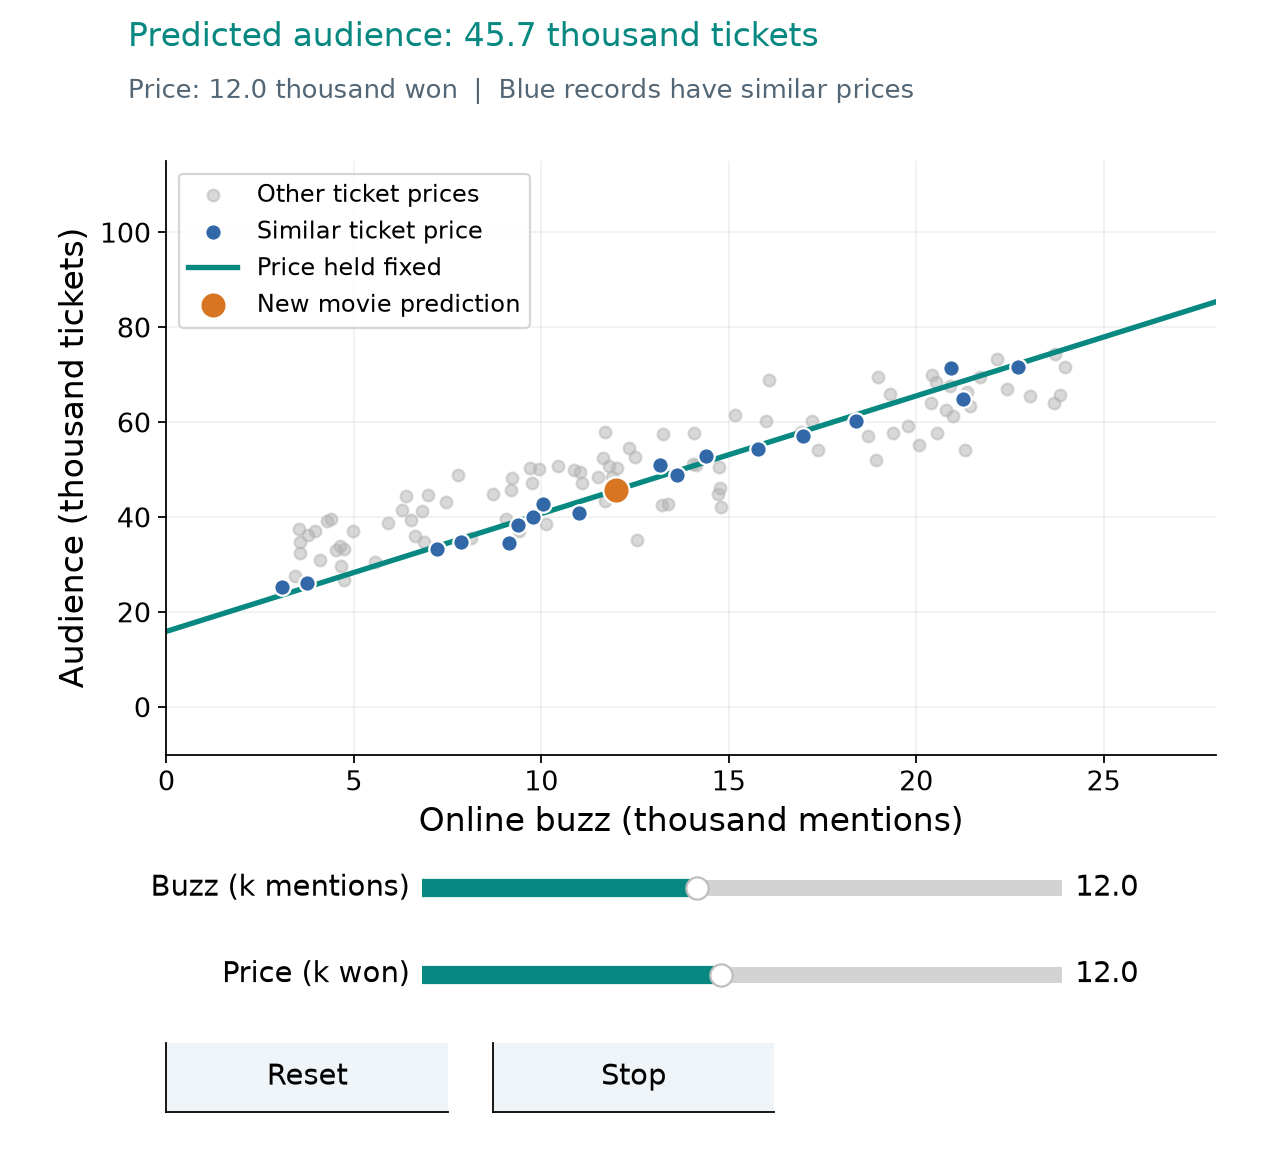

In [1]:
import os
import sys
import io
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            plt.show()
            try:
                while self.running and plt.fignum_exists(self.figure.number):
                    plt.pause(.04)
            finally:
                self.stop()
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show()

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)

rng_movie = np.random.default_rng(63)
buzz = rng_movie.uniform(3, 24, 160)
price = np.clip(7 + .32*buzz + rng_movie.normal(0, 2.0, 160), 6, 18)
audience = 40 + 2.5*buzz - 2*price + rng_movie.normal(0, 3, 160)
movie_inputs = np.column_stack([buzz, price])
order = rng_movie.permutation(len(audience))
movie_train, movie_test = order[:110], order[110:]
movie_model = LinearRegression().fit(movie_inputs[movie_train], audience[movie_train])
buzz_model = LinearRegression().fit(buzz[movie_train, None], audience[movie_train])
movie_test_error = metrics(audience[movie_test], movie_model.predict(movie_inputs[movie_test]))
buzz_test_error = metrics(audience[movie_test], buzz_model.predict(buzz[movie_test, None]))
buzz_grid = np.linspace(0, 28, 150)


def movie_context(ax, ticket_price):
    close = np.abs(price[movie_train]-ticket_price) <= .8
    ax.scatter(buzz[movie_train], audience[movie_train], color=".7", alpha=.5,
               s=28, label="Other ticket prices")
    ax.scatter(buzz[movie_train][close], audience[movie_train][close], color=BLUE,
               edgecolor="white", s=55, zorder=4, label="Similar ticket price")
    ax.set(xlabel="Online buzz (thousand mentions)", ylabel="Audience (thousand tickets)",
           xlim=(0, 28), ylim=(-10, 115))
    return close


def render_movie_query(view, online_buzz, ticket_price):
    query = np.array([[online_buzz, ticket_price]])
    prediction = float(movie_model.predict(query)[0])
    line = movie_model.predict(np.column_stack([buzz_grid, np.full(len(buzz_grid), ticket_price)]))
    ax = view.ax
    close = movie_context(ax, ticket_price)
    ax.plot(buzz_grid, line, color=TEAL, label="Price held fixed")
    ax.scatter([online_buzz], [prediction], color=ORANGE, edgecolor="white", s=140,
               zorder=5, label="New movie prediction")
    ax.legend(loc="upper left")
    view.status.set_text(f"Predicted audience: {prediction:.1f} thousand tickets")
    view.detail.set_text(f"Price: {ticket_price:.1f} thousand won  |  Blue records have similar prices")
    return {"prediction": prediction, "query": query, "nearby": close, "line": line}


movie_query_demo = RegressionExplorer("movie_query", render_movie_query, [
    ("online_buzz", "Buzz (k mentions)", 0, 28, 12, .5, "%0.1f"),
    ("ticket_price", "Price (k won)", 5, 20, 12, .5, "%0.1f"),
])
movie_query_demo.start()


## What if the model ignores the ticket price?

The purple model uses buzz alone. Its prediction cannot respond when the price control changes. The teal model uses both clues, so a price change moves its prediction.

The error scores use a separate set of movie releases that neither model fitted. Adding an informative input improves predictions here. Adding more inputs is not automatically helpful: irrelevant clues or duplicate information can add complexity without improving predictions.


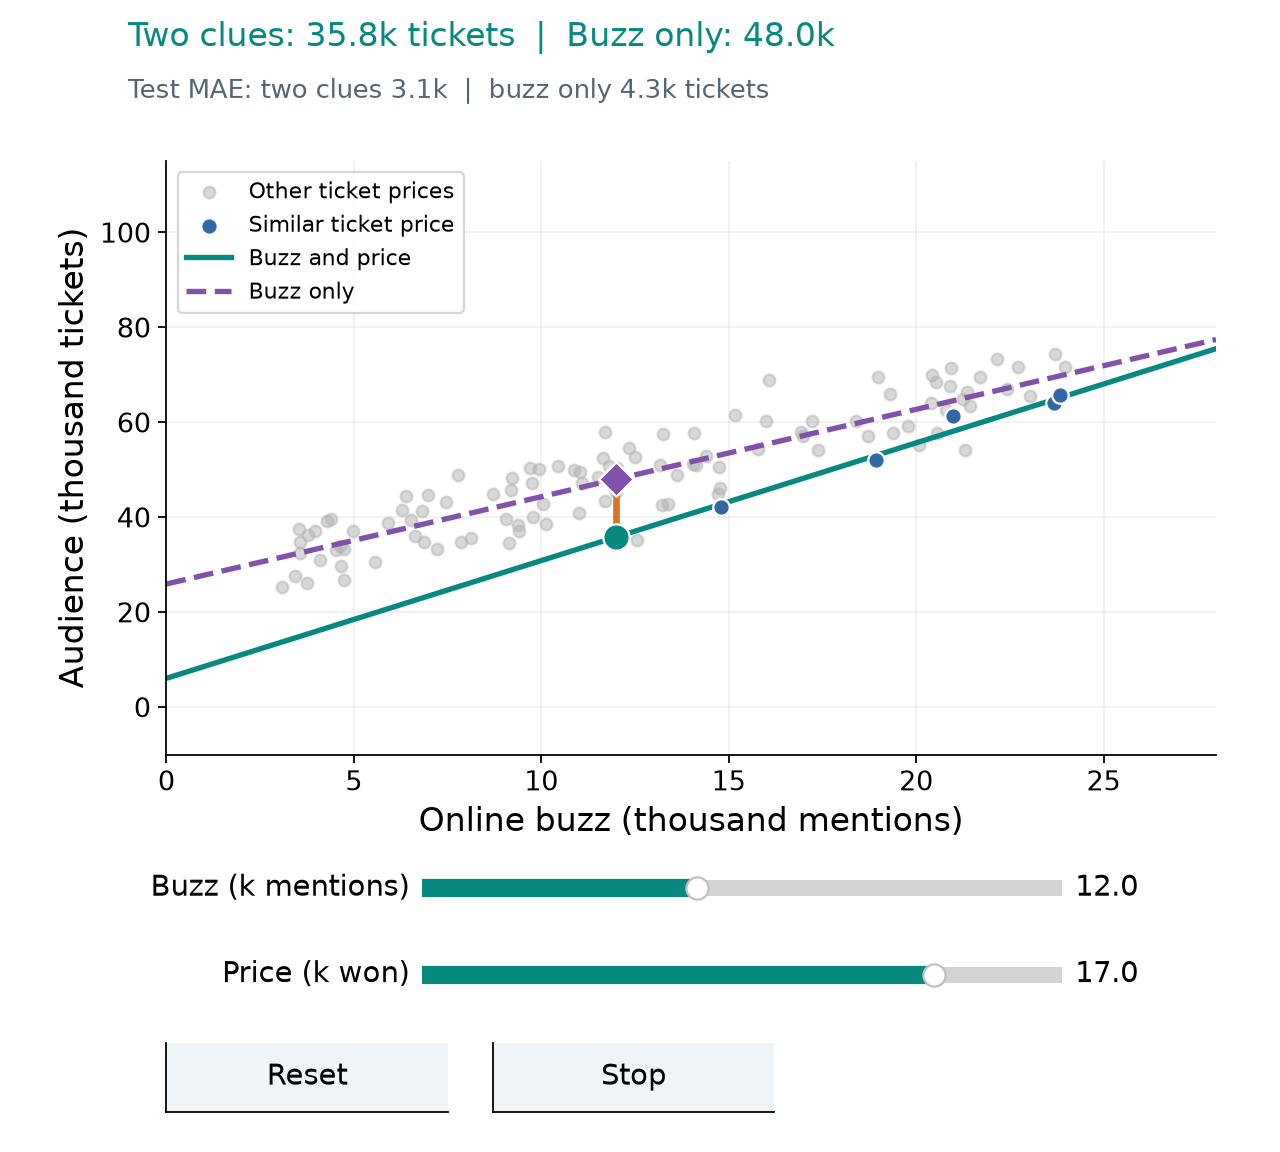

In [2]:
def render_missing_price(view, online_buzz, ticket_price):
    full = float(movie_model.predict([[online_buzz, ticket_price]])[0])
    limited = float(buzz_model.predict([[online_buzz]])[0])
    ax = view.ax
    movie_context(ax, ticket_price)
    full_line = movie_model.predict(np.column_stack([buzz_grid, np.full(len(buzz_grid), ticket_price)]))
    ax.plot(buzz_grid, full_line, color=TEAL, label="Buzz and price")
    ax.plot(buzz_grid, buzz_model.predict(buzz_grid[:, None]), "--", color=PURPLE, label="Buzz only")
    ax.scatter([online_buzz], [full], color=TEAL, s=140, edgecolor="white", zorder=5)
    ax.scatter([online_buzz], [limited], color=PURPLE, s=120, marker="D", edgecolor="white", zorder=5)
    ax.vlines(online_buzz, min(full, limited), max(full, limited), color=ORANGE, linewidth=3)
    ax.legend(loc="upper left", fontsize=10)
    view.status.set_text(f"Two clues: {full:.1f}k tickets  |  Buzz only: {limited:.1f}k")
    view.detail.set_text(f"Test MAE: two clues {movie_test_error['MAE']:.1f}k  |  buzz only {buzz_test_error['MAE']:.1f}k tickets")
    return {"full": full, "limited": limited, "full_line": full_line}


movie_missing_demo = RegressionExplorer("movie_missing", render_missing_price, [
    ("online_buzz", "Buzz (k mentions)", 0, 28, 12, .5, "%0.1f"),
    ("ticket_price", "Price (k won)", 5, 20, 17, .5, "%0.1f"),
])
movie_missing_demo.start()


## Familiar clues can make an unfamiliar combination

The map places each training movie by its buzz and price. Higher-buzz movies tend to cost more in this simulated dataset. A very cheap, heavily discussed movie may have few close neighbors even when both inputs fall inside their separate recorded ranges.

The orange marker moves across this map. Blue markers show nearby input combinations. The neighborhood is only a visual check of data coverage, not a confidence interval. Few nearby examples give less support for a prediction, and a familiar pair does not guarantee an accurate result.

An extrapolated line can even predict a negative audience. Such a result is a model failure, not a meaningful ticket count.


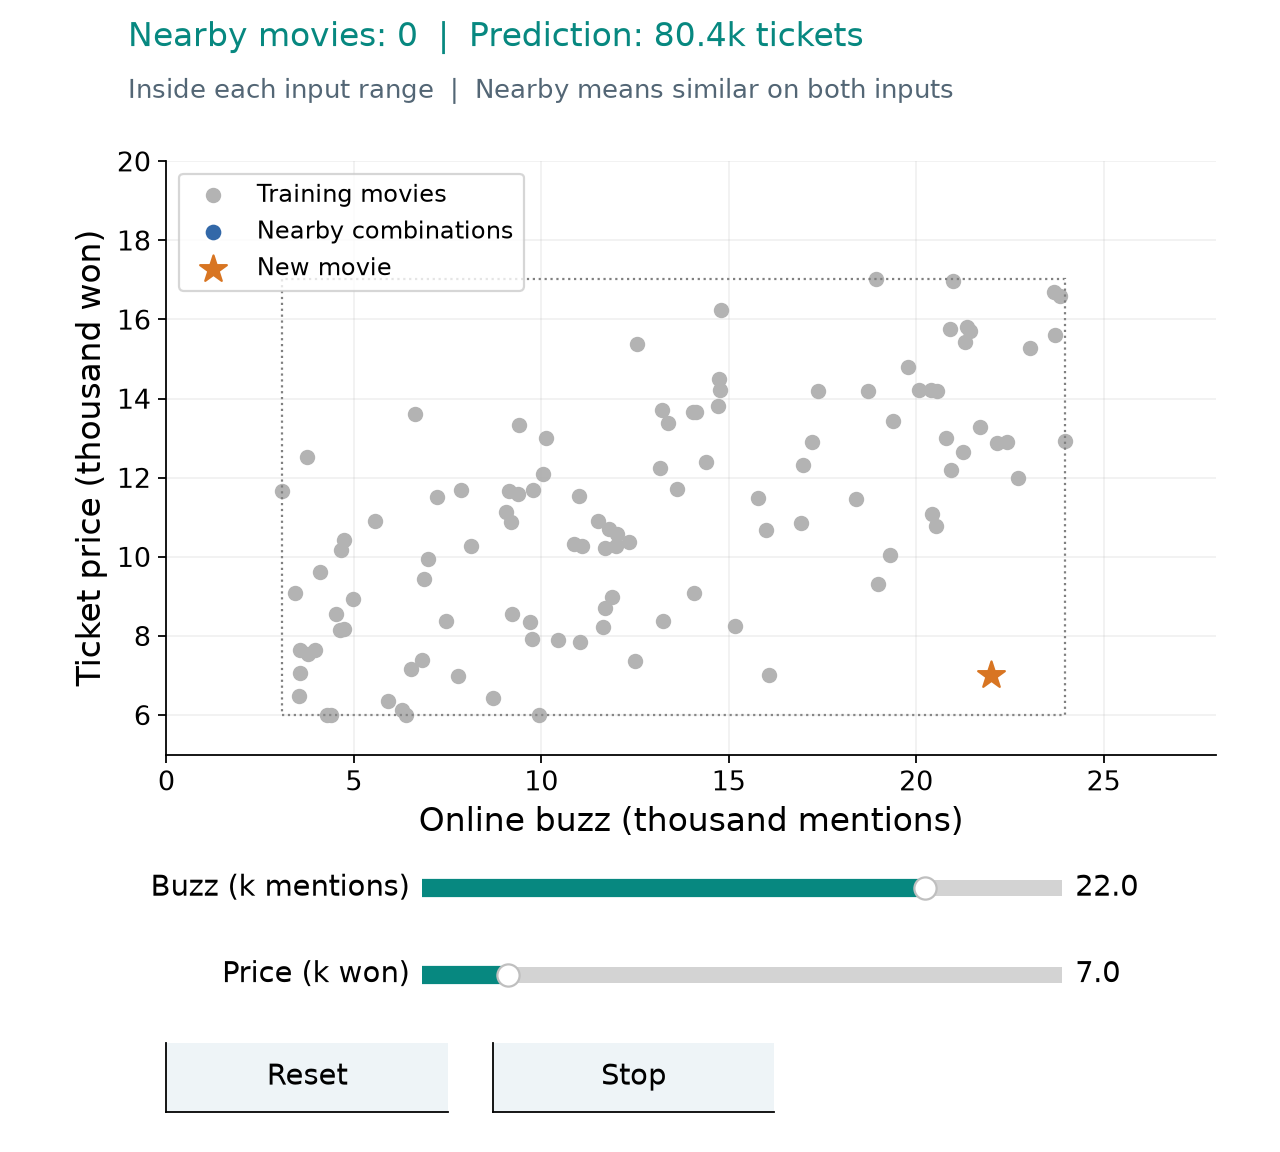

In [3]:
movie_scale = np.ptp(movie_inputs[movie_train], axis=0)


def render_movie_coverage(view, online_buzz, ticket_price):
    query = np.array([online_buzz, ticket_price])
    distances = np.linalg.norm((movie_inputs[movie_train]-query)/movie_scale, axis=1)
    close = distances <= .15
    prediction = float(movie_model.predict(query[None, :])[0])
    lower, upper = movie_inputs[movie_train].min(axis=0), movie_inputs[movie_train].max(axis=0)
    in_ranges = bool(np.all((query >= lower) & (query <= upper)))
    ax = view.ax
    ax.scatter(buzz[movie_train], price[movie_train], color=".7", s=35, label="Training movies")
    ax.scatter(buzz[movie_train][close], price[movie_train][close], color=BLUE, s=65,
               edgecolor="white", zorder=4, label="Nearby combinations")
    ax.scatter([online_buzz], [ticket_price], color=ORANGE, s=160, marker="*", zorder=5,
               label="New movie")
    ax.add_patch(Rectangle(lower, *(upper-lower), fill=False, linestyle=":", edgecolor=".5"))
    ax.set(xlabel="Online buzz (thousand mentions)", ylabel="Ticket price (thousand won)",
           xlim=(0, 28), ylim=(5, 20))
    ax.legend(loc="upper left")
    view.status.set_text(f"Nearby movies: {close.sum()}  |  Prediction: {prediction:.1f}k tickets")
    region = "Inside each input range" if in_ranges else "Outside at least one input range"
    view.detail.set_text(f"{region}  |  Nearby means similar on both inputs")
    return {"query": query, "nearby": close, "in_ranges": in_ranges, "prediction": prediction}


movie_coverage_demo = RegressionExplorer("movie_coverage", render_movie_coverage, [
    ("online_buzz", "Buzz (k mentions)", 0, 28, 22, .5, "%0.1f"),
    ("ticket_price", "Price (k won)", 5, 20, 7, .5, "%0.1f"),
])
movie_coverage_demo.start()
